# FLIP-IT CKD — simulating the federation: many clinics, one global model

This notebook simulates what FLIP-IT does in production: **GP practices, each with their own
patients, train one shared CKD model with Flower — without any practice sharing patient data.**

The arc:
1. We start with the single shipped placeholder dataset — it has **no signal**, so models score ~0.5.
2. We bring in **other clinics' data** (synthetic stand-ins for each practice's `extract_features.sql`
   extract), each a different non-IID population but the *same* underlying CKD biology.
3. A model trained at **one clinic doesn't generalize** to the rest of the network.
4. **Federated learning with Flower** (FedAvg for `logreg`/`mlp`, FedXgbBagging for `xgboost`)
   recovers ~the centralized pooled-data performance — beating the typical single clinic —
   **without moving any data**.

> **Synthetic note:** the clinic data carries real signal as an honest stand-in for the
> eGFR/HbA1c-bearing real data. The absolute numbers will change with the real extracts; the
> *federation effect* is the point.

In [1]:
# Repo root on sys.path so project modules import from notebooks/.
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from flwr.common import Code, FitRes, Parameters, Status
from flwr.server.strategy import FedXgbBagging

from data import load_dataframe, to_xy
from data.synthesize import generate_clinics
from models import make_model
from models.fedxgb import XgbPractice, predict_pooled, train_pooled
from simulate import fedavg            # real Flower FedAvg (aggregate_fit) under the hood
from task import compute_metrics, fit_scaler

_OK = Status(Code.OK, "")
print("ready")

2026-06-02 15:23:48,170	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


ready


## 1. The starting point — one signal-less dataset

The shipped `synthetic_ckd_data.csv` is a wiring placeholder: no feature actually predicts the
label, so even XGBoost (the strongest model we federate), trained on the *pooled* data, lands at
chance.

In [2]:
df0 = load_dataframe()
X0, y0 = to_xy(df0)
rng = np.random.default_rng(0)
perm = rng.permutation(len(X0)); X0, y0 = X0[perm], y0[perm]
s = int(len(X0) * 0.8)
bst0 = train_pooled(X0[:s], y0[:s])
auc0 = compute_metrics(y0[s:], predict_pooled(bst0, X0[s:]))["auc"]
maxcorr = max(abs(np.corrcoef(X0[:, j], y0)[0, 1]) for j in range(X0.shape[1]))
print(f"shipped dataset  : n={len(df0)}  CKD rate={y0.mean():.0%}")
print(f"max |feature-label correlation| : {maxcorr:.3f}   (basically zero)")
print(f"centralized XGBoost AUROC        : {auc0:.3f}   (chance — no signal to learn)")

shipped dataset  : n=2000  CKD rate=52%
max |feature-label correlation| : 0.031   (basically zero)
centralized XGBoost AUROC        : 0.511   (chance — no signal to learn)


## 2. Bring in other clinics

`data/synthesize.py` generates one dataset per clinic — each the simulated output of running
`extract_features.sql` at that practice. Clinics differ by **archetype** (urban-young,
rural-elderly, metabolic, high-CVD, mixed) in age, comorbidity prevalence, CKD rate and panel size
(**non-IID** on all three axes), but they share **one true CKD risk model** — the biology a global
model should learn. Generate them on disk with `uv run ckd-clinics`; here we build them in memory.

In [3]:
clinics = generate_clinics(num_clinics=10, base_seed=42)

rows = []
for cid, name, d in clinics:
    Xc, yc = to_xy(d)
    mc = max(abs(np.corrcoef(Xc[:, j], yc)[0, 1]) for j in range(Xc.shape[1]))
    rows.append({"clinic": cid, "archetype": name, "patients": len(d),
                 "CKD_rate": round(float(yc.mean()), 2), "max|corr|": round(mc, 2)})
clinic_table = pd.DataFrame(rows).set_index("clinic")
print("Each clinic is a different non-IID population, but features now carry real signal:")
clinic_table

Each clinic is a different non-IID population, but features now carry real signal:


,archetype,patients,CKD_rate,max|corr|
clinic,,,,
0,urban-young,162,0.10,0.30
1,rural-elderly,492,0.43,0.37
2,metabolic,434,0.35,0.37
3,high-cvd,331,0.42,0.30
4,mixed,328,0.18,0.36
5,urban-young,532,0.08,0.22
6,rural-elderly,161,0.46,0.36
7,metabolic,455,0.40,0.43
8,high-cvd,216,0.44,0.28


## 3. Set up the federation harness

Standard per-clinic preprocessing (local 80/20 split, local `StandardScaler` for the linear/NN
models — data never leaves the clinic). "Network AUROC" pools every clinic's local-test
predictions into one score, so we measure how well a model works **across the whole network**.

In [4]:
def split(X, y, seed, frac=0.2):
    r = np.random.default_rng(seed)
    p = r.permutation(len(X)); X, y = X[p], y[p]
    k = int(len(X) * (1 - frac))
    return X[:k], y[:k], X[k:], y[k:]


def prepare(clinics, seed=0):
    out = []
    for cid, name, d in clinics:
        X, y = to_xy(d)
        Xtr, ytr, Xte, yte = split(X, y, seed + cid)
        sc = fit_scaler(Xtr)
        out.append({"cid": cid, "name": name, "n": len(d),
                    "Xtr": Xtr, "ytr": ytr, "Xte": Xte, "yte": yte,
                    "Xtr_s": sc.transform(Xtr), "Xte_s": sc.transform(Xte)})
    return out


def net_auc(pairs):  # pairs: [(proba, y), ...] across clinics -> one network AUROC
    ps = np.concatenate([p for p, _ in pairs]); ys = np.concatenate([y for _, y in pairs])
    return compute_metrics(ys, ps)["auc"]


# --- linear / NN (FedAvg) ---
def lin_predict(weights, model, c):
    m = make_model(model, seed=0); m.initialize(c["Xte_s"].shape[1]); m.set_parameters(weights)
    return m.predict_proba(c["Xte_s"])

def lin_net_auc(weights, model, P):
    return net_auc([(lin_predict(weights, model, c), c["yte"]) for c in P])

def lin_train_local(model, c, epochs=60):
    m = make_model(model, seed=0); m.initialize(c["Xtr_s"].shape[1])
    m.fit(c["Xtr_s"], c["ytr"], epochs=epochs)
    return m.get_parameters()

def lin_train_central(model, P, epochs=60):
    Xtr = np.concatenate([c["Xtr"] for c in P]); ytr = np.concatenate([c["ytr"] for c in P])
    sc = fit_scaler(Xtr); m = make_model(model, seed=0); m.initialize(Xtr.shape[1])
    m.fit(sc.transform(Xtr), ytr, epochs=epochs)
    return m.get_parameters()

def lin_train_federated(model, P, rounds=20):
    """Real Flower FedAvg across clinics (fedavg() drives flwr.server.strategy.FedAvg)."""
    g = make_model(model, seed=0); g.initialize(P[0]["Xtr_s"].shape[1]); params = g.get_parameters()
    clients = [make_model(model, seed=0) for _ in P]
    for m in clients:
        m.initialize(P[0]["Xtr_s"].shape[1])
    for _ in range(rounds):
        updates = []
        for m, c in zip(clients, P):
            m.set_parameters(params); m.fit(c["Xtr_s"], c["ytr"], epochs=2)
            updates.append((m.get_parameters(), len(c["ytr"])))
        params = fedavg(updates)
    return params


# --- xgboost (FedXgbBagging) ---
def xgb_net_auc(bst, P):
    return net_auc([(bst.predict(xgb.DMatrix(c["Xte"])), c["yte"]) for c in P])

def xgb_net_auc_pooled(booster, P):
    return net_auc([(predict_pooled(booster, c["Xte"]), c["yte"]) for c in P])

def xgb_train_federated(P, rounds=20):
    """Real Flower FedXgbBagging across clinics."""
    prac = [XgbPractice(c["Xtr"], c["ytr"], c["Xte"], c["yte"], num_local_round=2, seed=0) for c in P]
    strat, gm = FedXgbBagging(), None
    for r in range(1, rounds + 1):
        fits = [(None, FitRes(status=_OK, num_examples=p.num_examples, metrics={},
                              parameters=Parameters(tensor_type="", tensors=[p.local_trees(gm)])))
                for p in prac]
        gm = strat.aggregate_fit(r, fits, [])[0].tensors[0]
    bst = xgb.Booster(); bst.load_model(bytearray(gm))
    return bst


P = prepare(clinics)
print(f"prepared {len(P)} clinics (sizes {[c['n'] for c in P]})")

prepared 10 clinics (sizes [162, 492, 434, 331, 328, 532, 161, 455, 216, 165])


## 4. A model trained at one clinic doesn't generalize

Train each clinic's model on **its own data only**, then score it **across the whole network**.
Most single-clinic models generalize poorly — a clinic only ever sees its own slice of patients.

In [5]:
single = {m: [lin_net_auc(lin_train_local(m, c), m, P) for c in P] for m in ("logreg", "mlp")}
single["xgboost"] = [xgb_net_auc_pooled(train_pooled(c["Xtr"], c["ytr"]), P) for c in P]

for m in ("logreg", "mlp", "xgboost"):
    s = single[m]
    print(f"{m:>7}: single-clinic network AUROC  mean={np.mean(s):.3f}  "
          f"range=[{min(s):.3f}, {max(s):.3f}]")

 logreg: single-clinic network AUROC  mean=0.707  range=[0.406, 0.778]
    mlp: single-clinic network AUROC  mean=0.728  range=[0.598, 0.780]
xgboost: single-clinic network AUROC  mean=0.760  range=[0.561, 0.820]


## 5. Federated learning with Flower — the payoff

Now train **one global model across all clinics with Flower** (FedAvg for `logreg`/`mlp`,
FedXgbBagging for `xgboost`) and compare against (a) the **typical single clinic** and (b) the
**centralized pooled-data ceiling** (not allowed in reality — all data in one place).

In [6]:
results = {}
for m in ("logreg", "mlp"):
    results[m] = {
        "single (avg clinic)": float(np.mean(single[m])),
        "federated (Flower)": lin_net_auc(lin_train_federated(m, P), m, P),
        "centralized (ceiling)": lin_net_auc(lin_train_central(m, P), m, P),
    }
all_X = np.concatenate([c["Xtr"] for c in P]); all_y = np.concatenate([c["ytr"] for c in P])
results["xgboost"] = {
    "single (avg clinic)": float(np.mean(single["xgboost"])),
    "federated (Flower)": xgb_net_auc(xgb_train_federated(P), P),
    "centralized (ceiling)": xgb_net_auc_pooled(train_pooled(all_X, all_y), P),
}
summary = pd.DataFrame(results).T[["single (avg clinic)", "federated (Flower)", "centralized (ceiling)"]]
summary.round(3)

,single (avg clinic),federated (Flower),centralized (ceiling)
logreg,0.707,0.785,0.788
mlp,0.728,0.743,0.770
xgboost,0.760,0.797,0.836


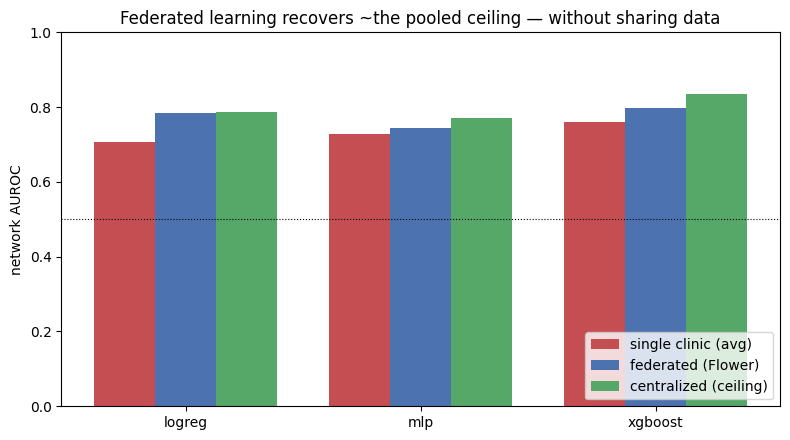

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
models = list(summary.index)
x = np.arange(len(models))
w = 0.26
ax.bar(x - w, summary["single (avg clinic)"], w, label="single clinic (avg)", color="#C44E52")
ax.bar(x,     summary["federated (Flower)"], w, label="federated (Flower)", color="#4C72B0")
ax.bar(x + w, summary["centralized (ceiling)"], w, label="centralized (ceiling)", color="#55A868")
ax.axhline(0.5, color="k", lw=0.8, ls=":")
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylim(0, 1); ax.set_ylabel("network AUROC")
ax.set_title("Federated learning recovers ~the pooled ceiling — without sharing data")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 6. Federation helps the data-poor clinics the most

The clearest win: a **small or skewed clinic** can't learn a good CKD model alone, but the federated
global model gives it a strong one. Below, for XGBoost, each clinic's **own-data model** vs the
**federated** model, both scored on that clinic's local test — sorted by clinic size.

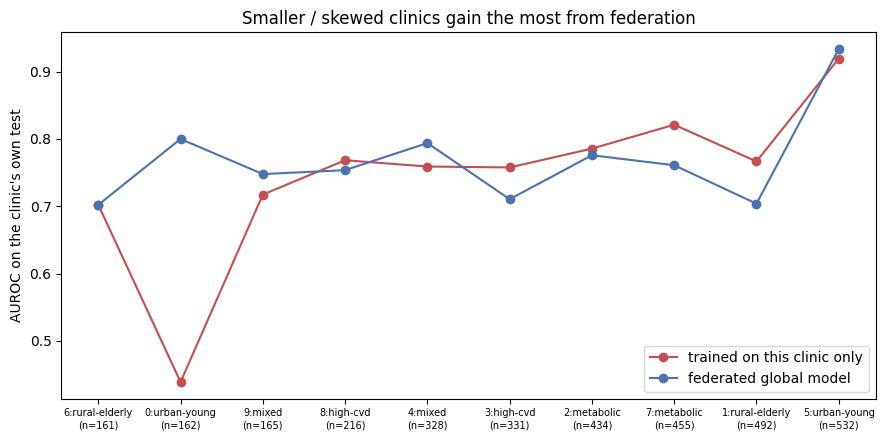

In [8]:
fed_bst = xgb_train_federated(P)
order = sorted(range(len(P)), key=lambda i: P[i]["n"])
local_auc, fed_auc, sizes, names = [], [], [], []
for i in order:
    c = P[i]
    own = train_pooled(c["Xtr"], c["ytr"])
    local_auc.append(compute_metrics(c["yte"], predict_pooled(own, c["Xte"]))["auc"])
    fed_auc.append(compute_metrics(c["yte"], fed_bst.predict(xgb.DMatrix(c["Xte"])))["auc"])
    sizes.append(c["n"]); names.append(f'{c["cid"]}:{c["name"]}')

xx = np.arange(len(order))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(xx, local_auc, "-o", label="trained on this clinic only", color="#C44E52")
ax.plot(xx, fed_auc, "-o", label="federated global model", color="#4C72B0")
ax.set_xticks(xx); ax.set_xticklabels([f"{n}\n(n={s})" for n, s in zip(names, sizes)], fontsize=7)
ax.set_ylabel("AUROC on the clinic's own test")
ax.set_title("Smaller / skewed clinics gain the most from federation")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

## Takeaways

- **One clinic isn't enough.** A model trained at a single practice generalizes poorly across the
  network — and data-poor clinics can't learn a good CKD model at all.
- **Flower federation ≈ the centralized ceiling, without moving data.** FedAvg (`logreg`/`mlp`) and
  FedXgbBagging (`xgboost`) recover most of the pooled-data performance while every patient row stays
  inside its practice — exactly the FLIP-IT promise.
- **This is the simulation of the real system.** Swap the synthetic clinics for the real
  `extract_features.sql` extracts (with eGFR/HbA1c) and the same machinery runs the 25-practice
  pilot — the absolute AUROC rises, the federation benefit remains.

Generate the clinic CSVs on disk with `uv run ckd-clinics` (or `make clinics`); run a federated
training end-to-end with `uv run ckd-simulate --model xgboost`.